# Analysis of Factors Asociated with Catalogue Purchases
### Name: Jinghan Zhang
### Group: 11: CWL2
### Group Members: Bowen Cui, CC Liang, Jinghan Zhang, Wendi Ke

In [1]:
install.packages('tidyverse')
install.packages('forcats')
install.packages('knitr')
install.packages('vtable')
install.packages('lubridate')
install.packages('tidymodels')
install.packages('glmnet')
install.packages('car')

library(tidyverse)
library(knitr)
library(naniar)
library(vtable)
library(forcats)
library(lubridate)
library(tidymodels)
library(glmnet)
library(car)

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr

## Data Description

The dataset contains information about the demographics and purchasing behaviour of customers. Along with basic demographic information such as age, income, marital status, and so on, it details the amount of money the customer spent on various types of products, their behaviour regarding products on discount, and the channels through which they interact with the products (online, in-store, catalogue purchases; web visits). The purpose of the dataset is to help businesses modify their product to target different customers by providing an understanding of customer behaviour. 

In [2]:
marketing_campaign <- read_tsv("https://raw.githubusercontent.com/wend1k3/CWL2-STAT-301/refs/heads/main/marketing_campaign.csv")
num_observations <- nrow(marketing_campaign)
num_variables <- ncol(marketing_campaign)
name_type_table <- data.frame(
    variable = names(marketing_campaign),
    type = sapply(marketing_campaign, class))
row.names(name_type_table) <- NULL

Rows: 2240 Columns: 29
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (3): Education, Marital_Status, Dt_Customer
dbl (26): ID, Year_Birth, Income, Kidhome, Teenhome, Recency, MntWines, MntF...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [3]:
print(paste('There are ', num_observations, ' observations, and ', num_variables, ' variables in the dataset.'))

[1] "There are  2240  observations, and  29  variables in the dataset."


In [4]:
kable(name_type_table) #data types



|variable            |type      |
|:-------------------|:---------|
|ID                  |numeric   |
|Year_Birth          |numeric   |
|Education           |character |
|Marital_Status      |character |
|Income              |numeric   |
|Kidhome             |numeric   |
|Teenhome            |numeric   |
|Dt_Customer         |character |
|Recency             |numeric   |
|MntWines            |numeric   |
|MntFruits           |numeric   |
|MntMeatProducts     |numeric   |
|MntFishProducts     |numeric   |
|MntSweetProducts    |numeric   |
|MntGoldProds        |numeric   |
|NumDealsPurchases   |numeric   |
|NumWebPurchases     |numeric   |
|NumCatalogPurchases |numeric   |
|NumStorePurchases   |numeric   |
|NumWebVisitsMonth   |numeric   |
|AcceptedCmp3        |numeric   |
|AcceptedCmp4        |numeric   |
|AcceptedCmp5        |numeric   |
|AcceptedCmp1        |numeric   |
|AcceptedCmp2        |numeric   |
|Complain            |numeric   |
|Z_CostContact       |numeric   |
|Z_Revenue  

### Summary of Data

Note: The data types of the variables in the raw data might not be the best representation of their semantic meanings or suitable for specific models. I will change them as needed during wrangling.


|Variable            |Type      | Description|
|:-------------------|:---------|:---|
|ID                  |numeric   | Unique ID |
|Year_Birth          |numeric   | Year of birth|
|Education           |character | Education level |
|Marital_Status      |character | Marital status |
|Income              |numeric   | Yearly income|
|Kidhome             |numeric   | Number of children in households|
|Teenhome            |numeric   | Number of teenagers in household|
|Dt_Customer         |character | Date of enrollment with company|
|Recency             |numeric   | Number of days since the last purchase|
|MntWines            |numeric   | Amount spent on wine in the previous 2 years|
|MntFruits           |numeric   | Amount spent on fruits in the previous 2 years|
|MntMeatProducts     |numeric   | Amount spent on meat in the previous 2 years|
|MntFishProducts     |numeric   | Amount spent on fish in the previous 2 years|
|MntSweetProducts    |numeric   | Amount spent on sweets in the previous 2 years|
|MntGoldProds        |numeric   | Amount spent on gold in the previous 2 years|
|NumDealsPurchases   |numeric   | Number of purchases made with a discount|
|NumWebPurchases     |numeric   | Number of purchases made through the website|
|NumCatalogPurchases |numeric   | Number of purchases made through the catalogue|
|NumStorePurchases   |numeric   | Number of purchases made in store|
|NumWebVisitsMonth   |numeric   | Number of website visits in the last month|
|AcceptedCmp3        |numeric   | Whether the customer accepted a promotion offer in the 3rd campaign - 1 if yes, 0 if no|
|AcceptedCmp4        |numeric   | Whether the customer accepted a promotion offer in the 4th campaign - 1 if yes, 0 if no|
|AcceptedCmp5        |numeric   | Whether the customer accepted a promotion offer in the 5th campaign - 1 if yes, 0 if no|
|AcceptedCmp1        |numeric   | Whether the customer accepted a promotion offer in the 1st campaign - 1 if yes, 0 if no|
|AcceptedCmp2        |numeric   | Whether the customer accepted a promotion offer in the 2nd campaign - 1 if yes, 0 if no|
|Complain            |numeric   | Whether the customer complained in the last 2 years - 1 if yes, 0 otherwise|
|Z_CostContact       |numeric   | No information provided|
|Z_Revenue           |numeric   | No information provided|
|Response            |numeric   | Whether the customer accepted a promotion offer in the most recent campaign - 1 if yes, 0 if no|


### Data Collection

There is no information on Kaggle regarding how the data was collected. Given the structure of the data, I will assume that the data comes from a company collecting data on its customers. This data is likely a small sample of the entire company's records or of a specific time period, given its relatively small size.

### Data Source
The data is from kaggle, by the user **imakash3011** at this link: https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis/data. The description in the data card notes that the dataset is provided by Dr. Omar Romero-Hernandez. There is no specific citation requested by the author, and the dataset is listed under a public domain license. 

An APA format citation of this dataset is:

imakash3011. (n.d.). _Customer Personality Analysis_. Kaggle. Retrieved March 14, 2026, from https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis

To read in the data, I have used a link from my group's GitHub repository.

## REVISED Question: Which Characteristics are Strongly Associated with the Number of Catalogue Purchases?
 
I want to understand which customer characteristics are the most relevant to catalogue purchases. This question focuses on inference--I want to understand which demographic or behaviour factors are the most strongly associated with catalogue purchases. The response variable will be NumCatalogPurchases, and I anticipate that the demographic variables, such as `Income`, `Year_Birth`, `Education`, `Marital_Status`, `Kidhome`, `Teenhome`, will be important. Behavioural variables with information regarding spending amounts of categories, as well as responses to campaigns, will likely be informative. I want to include the variables regarding the number of purchases through other channels, such as `NumWebPuchases` and `NumStorePurchases` to control for purchasing behaviour in other channels. Aside from `ID`--which I will drop because it's not informative, `Z_CostContact`, and `Z_Revenue`--which I will drop due to inadequate documentation, I will use every variable. 

## Exploratory Data Analysis and Visualization

In [5]:
#reading and loading data
marketing_campaign <- read_tsv("https://raw.githubusercontent.com/wend1k3/CWL2-STAT-301/refs/heads/main/marketing_campaign.csv")
head(marketing_campaign, 10)

Rows: 2240 Columns: 29
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (3): Education, Marital_Status, Dt_Customer
dbl (26): ID, Year_Birth, Income, Kidhome, Teenhome, Recency, MntWines, MntF...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,⋯,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
5524,1957,Graduation,Single,58138,0,0,04-09-2012,58,635,⋯,7,0,0,0,0,0,0,3,11,1
2174,1954,Graduation,Single,46344,1,1,08-03-2014,38,11,⋯,5,0,0,0,0,0,0,3,11,0
4141,1965,Graduation,Together,71613,0,0,21-08-2013,26,426,⋯,4,0,0,0,0,0,0,3,11,0
6182,1984,Graduation,Together,26646,1,0,10-02-2014,26,11,⋯,6,0,0,0,0,0,0,3,11,0
5324,1981,PhD,Married,58293,1,0,19-01-2014,94,173,⋯,5,0,0,0,0,0,0,3,11,0
7446,1967,Master,Together,62513,0,1,09-09-2013,16,520,⋯,6,0,0,0,0,0,0,3,11,0
965,1971,Graduation,Divorced,55635,0,1,13-11-2012,34,235,⋯,6,0,0,0,0,0,0,3,11,0
6177,1985,PhD,Married,33454,1,0,08-05-2013,32,76,⋯,8,0,0,0,0,0,0,3,11,0
4855,1974,PhD,Together,30351,1,0,06-06-2013,19,14,⋯,9,0,0,0,0,0,0,3,11,1


#### Cleaning and Wrangling
The data is already in a tidy format, but I need to change the formatting of some of the data types and parse the dates, as well as drop the irrelevant columns.

In [6]:
unique(marketing_campaign$Education) #checking to create the correct ordering

[1] "Graduation" "PhD"        "Master"     "Basic"      "2n Cycle"

In [7]:
marketing_campaign <- marketing_campaign %>%
    mutate(
        Dt_Customer = dmy(Dt_Customer), #cleaning date formats
        Education = factor(Education, 
                          levels = c('Basic', '2n Cycle', 'Graduation', 'Master', 'PhD'),
                          ordered = TRUE), #making education a ordered factor
        Marital_Status = as.factor(Marital_Status) # making marital status a factor
    ) %>% 
    select(-ID, -Z_CostContact, -Z_Revenue) # dropping ID, and two variables that are not adequately described in the data source

#### Missing Values

In [8]:
miss_var_summary(marketing_campaign)

variable,n_miss,pct_miss
<chr>,<int>,<num>
Income,24,1.07
Year_Birth,0,0
Education,0,0
Marital_Status,0,0
Kidhome,0,0
Teenhome,0,0
Dt_Customer,0,0
Recency,0,0
MntWines,0,0


It seems like only `Income` has missing values, and because it is only missing ~1% of the values, and I anticipate income will be an important covariate, it should be ok to simply drop those observations. There are no other missing values, or any variables missing a large proportion.

In [9]:
marketing_campaign_dropna <- marketing_campaign %>% drop_na(Income)

In [10]:
num_observations_dropna <- nrow(marketing_campaign_dropna)
num_variables_dropna <- ncol(marketing_campaign_dropna)
print(paste('After dropping unused columns and observations with missing valees, there are now ', num_observations_dropna, ' observations, and ', num_variables_dropna, ' variables in the dataset.'))

[1] "After dropping unused columns and observations with missing valees, there are now  2216  observations, and  26  variables in the dataset."


#### Class Imbalance

I will look at `Marital_Status` first.

In [11]:
data.frame(table(marketing_campaign_dropna$Marital_Status)) %>% 
    rename(Count = Freq) %>% 
    mutate(Proportion = prop.table(Count))

Var1,Count,Proportion
<fct>,<int>,<dbl>
Absurd,2,0.0009025271
Alone,3,0.0013537906
Divorced,232,0.1046931408
Married,857,0.3867328520
Single,471,0.2125451264
Together,573,0.2585740072
Widow,76,0.0342960289
YOLO,2,0.0009025271


It seems like `Absurd`, `Alone`, and `YOLO` are outliers, with only 2-3 observations each. This could be problematic, because the `Marital_Status` variable is categorical and also probably relevant to the question. I think it's safe to assume that `Alone` and `YOLO` are similar enough to `Single`, so I will recode them. `Absurd` does not quite fit in with any of the common categories, and it seems like it might have been entered as a joke or a typo. Given how few observations there are and the fact that it does not fit in with anything else, I will drop it.

In [12]:
marketing_campaign_clean <- marketing_campaign_dropna %>% 
    filter(Marital_Status != 'Absurd') %>% #dropping extremely rare level
    droplevels() %>% #dropping unused level
    mutate(Marital_Status = fct_collapse(Marital_Status, Single = c('Single', 'Alone', 'YOLO'))) #combining 
data.frame(table(marketing_campaign_clean$Marital_Status)) %>% 
    rename(Count = Freq) %>% 
    mutate(Proportion = prop.table(Count))

Var1,Count,Proportion
<fct>,<int>,<dbl>
Single,476,0.21499548
Divorced,232,0.10478771
Married,857,0.38708220
Together,573,0.25880759
Widow,76,0.03432701


I will also take a look at `Education`, the other categorical variable.

In [13]:
data.frame(table(marketing_campaign_clean$Education)) %>% 
    rename(Count = Freq) %>% 
    mutate(Proportion = prop.table(Count))

Var1,Count,Proportion
<fct>,<int>,<dbl>
Basic,54,0.02439024
2n Cycle,200,0.09033424
Graduation,1115,0.50361337
Master,364,0.16440831
PhD,481,0.21725384


Education looks alright. `Basic` is quite rare, but there are a decent amount of observations, and it makes sense given the context. Next, I will take a look at all the binary response variables. 

In [14]:
binary_responses <- marketing_campaign_clean %>% 
    select(AcceptedCmp3, AcceptedCmp4, AcceptedCmp5, 
           AcceptedCmp1, AcceptedCmp2, Complain, Response) %>%
    pivot_longer(cols = everything()) %>% 
    group_by(name) %>%
    summarize(count_1s = sum(value == 1),
              count_0s = sum (value == 0),
              percent_1s = (100 * mean(value)))
    

binary_responses

name,count_1s,count_0s,percent_1s
<chr>,<int>,<int>,<dbl>
AcceptedCmp1,141,2073,6.3685637
AcceptedCmp2,30,2184,1.3550136
AcceptedCmp3,163,2051,7.3622403
AcceptedCmp4,164,2050,7.4074074
AcceptedCmp5,161,2053,7.2719061
Complain,21,2193,0.9485095
Response,332,1882,14.9954833


There is some class imbalance in that 1's (positive responses) are much less common than 0's, but the class imbalance is not too severe in most cases, and it's likely an accurate reflection of real-life behaviour. However, `Complain` and `AcceptedCmp2` have concerningly few positive observations. I will not drop these variables at the moment, but I will be cautious when using them in a model.

#### Outliers
Given that some variables represent real-life demographic information, I will check for 'unreasonable' values.

In [15]:
sumtable(marketing_campaign_clean, out = 'return')

Variable,N,Mean,Std. Dev.,Min,Pctl. 25,Pctl. 75,Max
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Year_Birth,2214,1969,12,1893,1959,1977,1996
Education,2214,,,,,,
... Basic,54,2%,,,,,
... 2n Cycle,200,9%,,,,,
... Graduation,1115,50%,,,,,
... Master,364,16%,,,,,
... PhD,481,22%,,,,,
Marital_Status,2214,,,,,,
... Single,476,21%,,,,,


I am concered with `Year_Birth` and `Income`. There seems to be a very early year and a very high income. 

In [16]:
earliest_year_birth <- head(sort(marketing_campaign_clean$Year_Birth, decreasing = FALSE), n = 5)
highest_income <- head(sort(marketing_campaign_clean$Income, decreasing = TRUE), n = 5)

print(paste('Earliest Birth Years: ', list(earliest_year_birth)))
print(paste('Highest Incomes: ', list(highest_income)))


[1] "Earliest Birth Years:  c(1893, 1899, 1900, 1940, 1941)"
[1] "Highest Incomes:  c(666666, 162397, 160803, 157733, 157243)"


The list of earliest birth years seems a little problematic. 1893, 1899, and 1900 are very early birth years. Perhaps they are due to misinputs or customers entering random birth years. Because there are only 3 concerning values, I will just drop them by setting the cutoff at 100 years ago. The very highest income also seems problematic--it is much higher than the next value down, and it's the same digit repeated. Perhaps it's a typo. Again, seeing as there is only one extreme outlier and it is likely an input error, I will just drop it by cutting income off at 200,000. 

In [17]:
marketing_campaign_clean <- marketing_campaign_clean %>% filter(Year_Birth >= (year(now()) - 100 ),
                                                                Income <= 200000)

#### Visualization

I want to plot the relationship between web visits and web purchases by age and education. I will create a grouped bar chart, faceted by demographic information, with the range or categories of the demographic on the x-axis and average web visits and average web purchases as a group of two bars on the y axis. 

I will include the following covariates in the facets: 
- `Year_Birth` (mutated to age in years for ease of interpretability, grouped for plotting)
- `Education`
- `Marital_Status`
- `Income` (grouped for plotting)

In [18]:
#wrangling to arrive at averages per group
marketing_campaign_plotting <- marketing_campaign_clean %>%
    mutate(Age = year(now()) - Year_Birth,
           Age_Group = case_when(
               Age < 30 ~ 'Under 30',
               Age >= 30 & Age < 40 ~ '30 to 39',
               Age >= 40 & Age < 50 ~ '40 to 49',
               Age >= 50 & Age < 65 ~ '50 to 64',
               Age >= 65 ~ 'Over 65'),
           Income_Group = case_when(
               Income < 45000 ~ 'Under $45,000',
               Income >= 45000 & Income < 100000 ~ '45,000 to 100,000',
               Income >= 100000 & Income < 150000 ~ '100,000 to 150,000',
               Income >= 150000 ~ 'Over 150,000')
           ) %>%
    select(Age_Group, Income_Group, Education, Marital_Status, NumStorePurchases, NumCatalogPurchases, NumWebPurchases
          ) %>%
    pivot_longer(
        cols = c(Age_Group, Income_Group, Education, Marital_Status),
        names_to = 'Demographic',
        values_to = 'Group'
    ) %>%
    group_by(Demographic, Group) %>%
    summarize(
        avg_cat_purchases = mean(NumCatalogPurchases),
        avg_store_purchases = mean(NumStorePurchases),
        avg_web_purchases = mean(NumWebPurchases),
    )%>%
    pivot_longer(
        cols = c(avg_store_purchases, avg_cat_purchases, avg_web_purchases),
        names_to = 'Variable',
        values_to = 'Average'
    ) %>% 
    mutate(
        Variable = dplyr::recode(
            Variable,
            avg_cat_purchases = 'Catalogue Purchases',
            avg_store_purchases = 'Store Purchases',
            avg_web_purchases = 'Website Purchases'),
        Demographic = dplyr::recode(
            Demographic, 
            Age_Group = 'Age Group',
            Income_Group = 'Income Group',
            Marital_Status = 'Marital Status'),
        Group = factor(
            Group,
            levels = c(
                'Under 30', '30 to 39', '40 to 49', '50 to 64', 'Over 65',
                'Under $45,000', '45,000 to 100,000', '100,000 to 150,000', 'Over 150,000',
                'Basic', 'Graduation', '2n Cycle', 'Master', 'PhD', #2n Cycle is similar to a master's degree
                'Single', 'Together', 'Married', 'Divorced', 'Widow'
                ),
            ordered = TRUE
        )
    ) 

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by Demographic and Group.
ℹ Output is grouped by Demographic.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(Demographic, Group))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


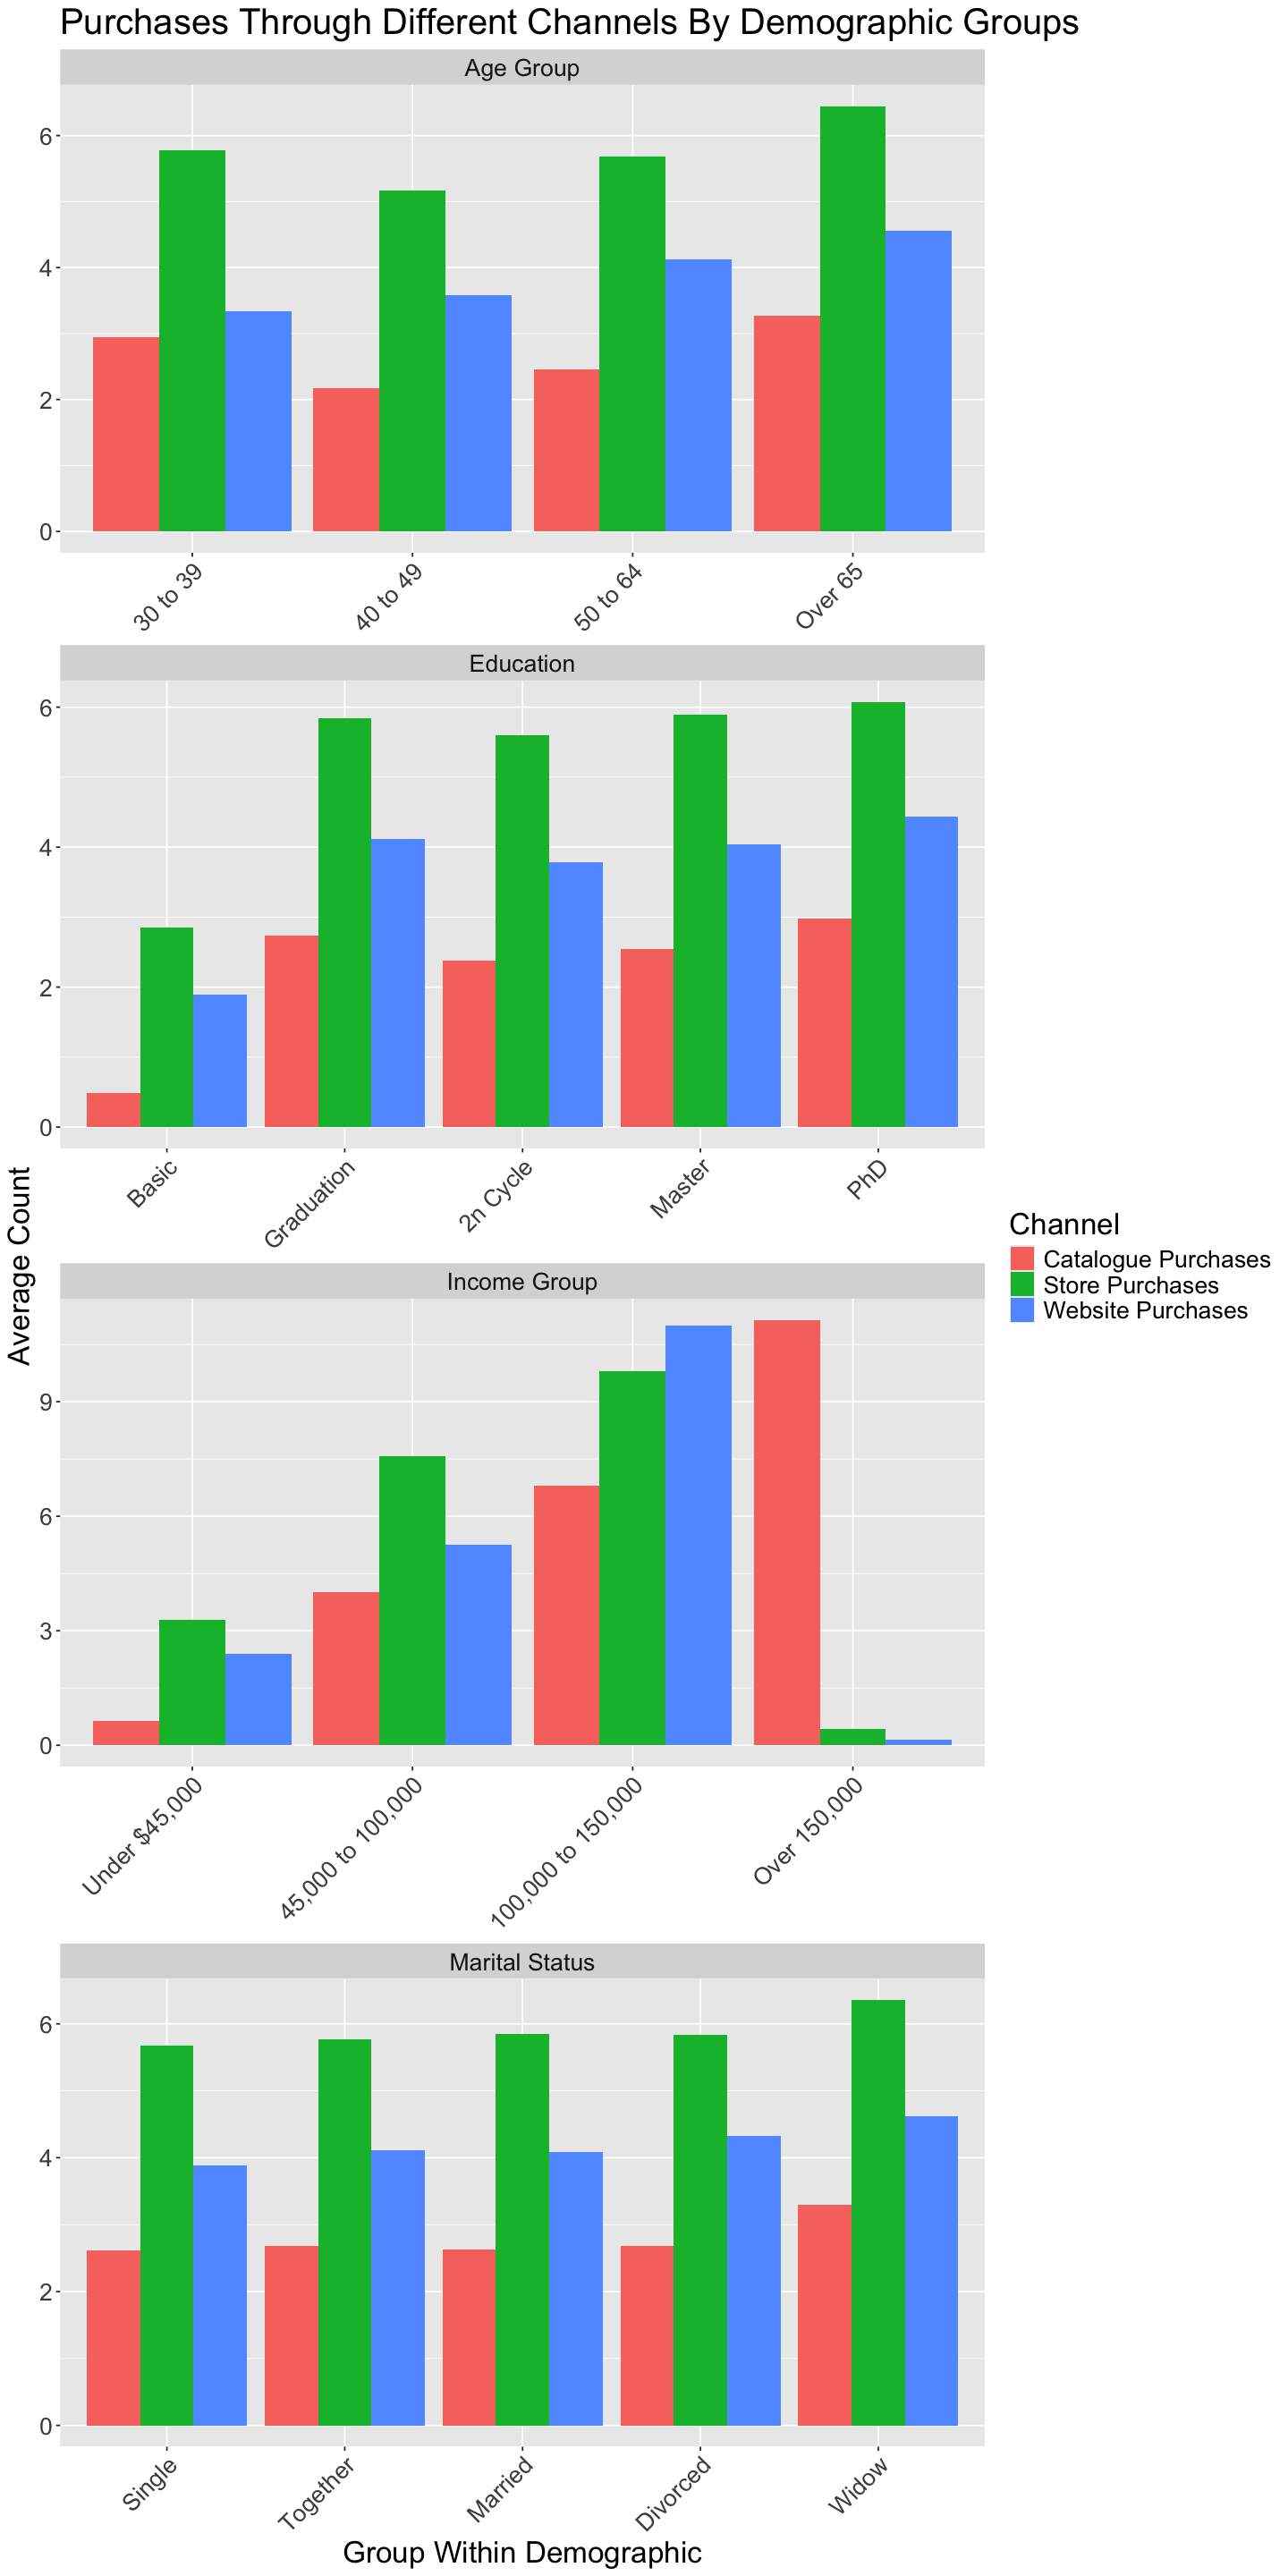

In [19]:
options(repr.plot.width=12, repr.plot.height=24)
marketing_campaign_plotting %>%
    ggplot(aes(x = Group, y = Average, fill = Variable)) +
    geom_bar(position = 'dodge', stat = 'identity') + 
    facet_wrap(~ Demographic, scales = 'free', ncol = 1) + 
    theme(
        axis.text.x = element_text(angle = 45, hjust = 1),
        text = element_text(size = 20)) +
    labs(
        y = 'Average Count',
        x = 'Group Within Demographic' ,
        fill = 'Channel') +
    ggtitle('Purchases Through Different Channels By Demographic Groups')

The visualization I have created is one that compares average purchases from the three different channels (store, web, catalogue). This allows for easy comparison between the averages of the same purchase channel between demographic groups, as well as easy comparison of the different purchasing channels within the same group. A stack bar chart, such as this plot, allows for the viewer to quickly find information such as the most popular purchase channel for each group, as well as compare the relative popularities within a group, and see the distribution across demographic variables.

Showing average figures is useful in this type of context--analysing customer behaviour for the purposes of improving business operations. I imagine that the audience for this type of analysis would prefer aggregate insights, even if it meant neglecting distributions and outliers. 
 


## Methods and Plan

To answer my question, I will use a Poisson regression with `NumCatalogPurchases` as the response variable. A Poisson regression model is the most appropriate method for this question because the response is a discrete, nonnegative count. No other method covered in the course can handle this type of response.

I will use LASSO to select covariates and tune the parameter lambda through cross-validation to ensure model quality. Afterwards, I will re-fit another model with the LASSO selected variables for inference. To make sure that I am not "double-dipping", I will split the data into separate selection and inference sets.

Given the large number of covariates and my goal of finding insights that are practical and applicable to business operations, using LASSO to select the most important variables is a good method. This way, I can answer the inferential aspect of my question regarding which variables are the most influential. Furthermore, tuning lambda through cross-validation will help me find the best fit. This addresses the predictive aspect of my question by fitting a model that gives more accurate predictions. Furthermore, LASSO is good for when the goal is to reduce the number of variables or identify the most influential ones, which is applicable to this type of question.

It is important to note that the model obtained directly from LASSO is not suitable for generative modelling, because the resulting estimator will be biased. To address this issue, I will take the variables selected by LASSO and re-fit another Poisson regression on the inference data set to ensure that the coefficients and SE's are valid. 

My plan relies on a few assumptions, mostly related to the Poisson regression method:

1. The variance and mean of the response are equal
2. Observations are independent from each other
3. Linearity - the log of the expected count is a linear function of the covariates

Due to the assumptions and the nature of the data, my project has some limitations:

1. No way to identify causal effects: The data is observational rather than experimental, thus I can only identify associations, not causal effects. Additionally, there is not much information on the data collection method--the data might be a biased sample, which further affects causal inference.
2. Multicollinearity: it's possible that there will be multicollinearity among the variables, especially because many of them are closely related. For example, income might be very closely related to the amount spent on certain categories, more purchases through one channel might correlate with fewer purchases through another, amount spent on a certain category might be correlated with number of purchases from a certain channel, and so on. This is particularly concerning because there is not much information regarding data collection--perhaps the business is structured in a way that will lead to collinearity between predictors, e.g. if meat is only available in stores, then the amount spent on meat and the number of in store purchases might be correlated.
3. Class Imbalance: Some of the covariates may be imbalanced, especially the campaign-related ones, where there are relatively few positive observations.
4. Violation of Poisson assumptions:
   - The Poisson regression assumes that the variance and the mean of the response are equal, but in practice, this is not always true. Often, there is **overdispersion**--the variance is higher than the mean.
   - The log of the expected counts may not necessarily be a linear function of the covariates.
       -  Many of the covariates relate to real-life demographic information, such as age and income. In real life, the effects of such variables are not always linear (e.g. spending amounts on food don't increase linearly with income because people can only eat so much food, no matter how much more they earn).
       -  My model will not include interactions, there might be some omitted variable bias.
       -  The response may be affected by class imbalance. If there are many zeros, the relationship may not be linear.
5. Categorical Variables and Poisson: Poisson selection might select only some dummies out of a set of categorical indicators, which poses a problem for interpretation because the coefficients are relative to the reference, rather than objective. 





## Computational Code and Output

### Notes on Data Wrangling
For the sake of interpretation, I am going to make the following changes:
1. Create an `Age` variable using the `Year_Birth` variable and the year 2021, when the dataset was uploaded, because age in years is much more intuitively understood than birth year.
2. Change the units of `Income` to thousands of dollars, to avoid very small coefficients.


In [20]:
marketing_campaign_clean <- marketing_campaign_clean %>% 
    mutate(
        Age = 2021 - Year_Birth,
        Income = Income/1000,
    )

sumtable(marketing_campaign_clean, out = 'return')

Variable,N,Mean,Std. Dev.,Min,Pctl. 25,Pctl. 75,Max
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Year_Birth,2210,1969,12,1940,1959,1977,1996
Education,2210,,,,,,
... Basic,54,2%,,,,,
... 2n Cycle,198,9%,,,,,
... Graduation,1114,50%,,,,,
... Master,364,16%,,,,,
... PhD,480,22%,,,,,
Marital_Status,2210,,,,,,
... Single,475,21%,,,,,


#### Data Splitting
To make sure there is no double dipping, I will split the data into separate selection and inference sets.

In [21]:
set.seed(123) #for reproducibility

marketing_split <- initial_split(marketing_campaign_clean, prop = 0.6)
marketing_selection <- training(marketing_split)
marketing_inference <- testing(marketing_split)

marketing_formula = NumCatalogPurchases ~.-Year_Birth

model_matrix_X_selection <- model.matrix(
    marketing_formula,
    marketing_selection
)[, -1]
matrix_Y_selection <- matrix(marketing_selection$NumCatalogPurchases, ncol = 1)
model_matrix_X_inference <- model.matrix(
    marketing_formula,
    marketing_inference
)[, -1]
matrix_Y_inference <- matrix(marketing_inference$NumCatalogPurchases, ncol = 1)


#### Fitting Poisson LASSO, Selecting Variables

In [22]:
set.seed(123)

marketing_cv_LASSO <- 
    cv.glmnet(
        x = model_matrix_X_selection,
        y = matrix_Y_selection,
        alpha = 1,
        family = 'poisson',
        type.measure = 'deviance',
        nfolds = 5)

lambda_1se_deviance_LASSO <- marketing_cv_LASSO$lambda.1se

marketing_cv_LASSO
lambda_1se_deviance_LASSO


Call:  cv.glmnet(x = model_matrix_X_selection, y = matrix_Y_selection,      type.measure = "deviance", nfolds = 5, alpha = 1, family = "poisson") 

Measure: Poisson Deviance 

     Lambda Index Measure      SE Nonzero
min 0.02229    50  0.9662 0.01744      26
1se 0.06808    38  0.9824 0.01654      19

[1] 0.06807593

In [23]:
coefs_marketing_LASSO <- coef(marketing_cv_LASSO, s = 'lambda.1se')
coefs_marketing_LASSO

32 x 1 sparse Matrix of class "dgCMatrix"
                          lambda.1se
(Intercept)             2.2371939128
Education.L             .           
Education.Q             .           
Education.C             .           
Education^4             .           
Marital_StatusDivorced  .           
Marital_StatusMarried   .           
Marital_StatusTogether  .           
Marital_StatusWidow     .           
Income                  0.0128036174
Kidhome                -0.4769751301
Teenhome               -0.0150143337
Dt_Customer            -0.0001536999
Recency                 .           
MntWines                0.0005602654
MntFruits               0.0004594632
MntMeatProducts         0.0002361731
MntFishProducts         0.0011788516
MntSweetProducts        0.0002743288
MntGoldProds            0.0011810784
NumDealsPurchases       0.0612405911
NumWebPurchases         0.0229034824
NumStorePurchases       0.0156733977
NumWebVisitsMonth      -0.0810875697
AcceptedCmp3            0.2996758

In [24]:
lasso_selected_covariates <- as_tibble(
        as.matrix(coefs_marketing_LASSO),
        rownames='covariate') %>%
        filter(covariate != '(Intercept)' & abs(lambda.1se) !=0) %>% 
        pull(covariate)

lasso_selected_covariates

selected_covariate_formula <- reformulate(
    termlabels = lasso_selected_covariates,
    response = "NumCatalogPurchases"
)

selected_covariate_formula

[1] "Income"            "Kidhome"           "Teenhome"         
 [4] "Dt_Customer"       "MntWines"          "MntFruits"        
 [7] "MntMeatProducts"   "MntFishProducts"   "MntSweetProducts" 
[10] "MntGoldProds"      "NumDealsPurchases" "NumWebPurchases"  
[13] "NumStorePurchases" "NumWebVisitsMonth" "AcceptedCmp3"     
[16] "AcceptedCmp5"      "AcceptedCmp2"      "Response"         
[19] "Age"

NumCatalogPurchases ~ Income + Kidhome + Teenhome + Dt_Customer + 
    MntWines + MntFruits + MntMeatProducts + MntFishProducts + 
    MntSweetProducts + MntGoldProds + NumDealsPurchases + NumWebPurchases + 
    NumStorePurchases + NumWebVisitsMonth + AcceptedCmp3 + AcceptedCmp5 + 
    AcceptedCmp2 + Response + Age

#### Checking for Multicollinearity


In [25]:
lasso_vif_check <- car::vif(lm(selected_covariate_formula,
                         data = marketing_selection))
data.frame(lasso_vif_check)

,lasso_vif_check
,<dbl>
Income,4.634884
Kidhome,1.879592
Teenhome,1.760979
Dt_Customer,1.302311
MntWines,3.126570
MntFruits,2.005214
MntMeatProducts,3.103240
MntFishProducts,2.151429
MntSweetProducts,1.961433


There does not seem to be a concerning presence of multicollinearity.
#### Checking for Overdispersion



In [26]:
marketing_quasipoisson <- summary(glm(
    formula = selected_covariate_formula,
    data = marketing_selection,
    family = quasipoisson))

marketing_quasipoisson


Call:
glm(formula = selected_covariate_formula, family = quasipoisson, 
    data = marketing_selection)

Coefficients:
                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)        4.230e+00  1.489e+00   2.842  0.00456 ** 
Income             1.200e-02  1.462e-03   8.212 5.19e-16 ***
Kidhome           -5.544e-01  5.782e-02  -9.587  < 2e-16 ***
Teenhome          -1.363e-01  4.138e-02  -3.294  0.00101 ** 
Dt_Customer       -2.793e-04  9.200e-05  -3.036  0.00245 ** 
MntWines           6.259e-04  6.151e-05  10.176  < 2e-16 ***
MntFruits          5.439e-04  3.882e-04   1.401  0.16140    
MntMeatProducts    8.761e-05  8.995e-05   0.974  0.33025    
MntFishProducts    1.213e-03  2.977e-04   4.075 4.87e-05 ***
MntSweetProducts   3.046e-04  3.688e-04   0.826  0.40909    
MntGoldProds       1.182e-03  2.815e-04   4.199 2.86e-05 ***
NumDealsPurchases  8.973e-02  8.989e-03   9.983  < 2e-16 ***
NumWebPurchases    3.301e-02  6.851e-03   4.818 1.62e-06 ***
NumStorePurchases  1.809e-

THhe dispersion parameter for quasipoisson family is not too different from 1, meaning that there is no strong indication of overdispersion,
#### Inference Model
Now, I will re-fit a poisson regression model using the selected variables for inference, using the inference data split.

In [27]:
inference_model_marketing <- glm(
    formula = selected_covariate_formula,
    data = marketing_inference,
    family = 'poisson')

In [28]:
results_table <- tidy(
    inference_model_marketing,
    conf.int = TRUE,
    conf.level = 0.95,
    exponentiate = TRUE #for interpretation of counts, rather than log counts
) %>% 
    filter(term != "(Intercept)") %>%
    arrange(desc(estimate)) %>%
    rename('exp(estimate)' = estimate)

knitr::kable(
  results_table,
  caption = "Poisson Regression Results for NumCatalogPurchases, sorted by exp(estimate)"
)



Table: Poisson Regression Results for NumCatalogPurchases, sorted by exp(estimate)

|term              | exp(estimate)| std.error|  statistic|   p.value|  conf.low| conf.high|
|:-----------------|-------------:|---------:|----------:|---------:|---------:|---------:|
|AcceptedCmp3      |     1.2499318| 0.0783648|  2.8468004| 0.0044161| 1.0695155| 1.4542904|
|AcceptedCmp2      |     1.2118941| 0.1490512|  1.2893857| 0.1972640| 0.8957181| 1.6082612|
|NumDealsPurchases |     1.1206559| 0.0126942|  8.9737321| 0.0000000| 1.0927598| 1.1485256|
|NumWebPurchases   |     1.0641977| 0.0112628|  5.5244636| 0.0000000| 1.0410236| 1.0880186|
|Response          |     1.0455694| 0.0607239|  0.7338397| 0.4630464| 0.9275839| 1.1769027|
|Income            |     1.0095515| 0.0015577|  6.1028081| 0.0000000| 1.0064256| 1.0125926|
|MntGoldProds      |     1.0013309| 0.0003845|  3.4587882| 0.0005426| 1.0005714| 1.0020809|
|MntMeatProducts   |     1.0010102| 0.0000986| 10.2387819| 0.0000000| 1.0008164| 1.001

### Interpretation

The variables with the strongest positive associations with expected count are `AcceptedCmp3`, `NumDealsPurchases`, `NumWebPurchases`, and `Response`, while the variables with the strongest negative associations with expected count are `Kidhome`, `AcceptedCmp5`, and `NumWebVisitsMonth`; some variables have p-values higher than any conventionally accepted level and cannot be interpreted as significant. One concern is that some of the binary response variables show class imbalance--which could be problematic for accurate estimates. I'm surprised that the behavioural variables are more impactful than the demographic ones, especially income and age, which both ended up having high p-values. 


### AI Tool Disclosure 
AI tools (ChatGPT 5.4) were used to debug code and check grammar.